<img src="rupixen-Q59HmzK38eQ-unsplash.jpg" alt="Someone is trying to purchase a produce online" width="500"/>

Online shopping decisions rely on how consumers engage with online store content. You work for a new startup company that has just launched a new online shopping website. The marketing team asks you, a new data scientist, to review a dataset of online shoppers' purchasing intentions gathered over the last year. Specifically, the team wants you to generate some insights into customer browsing behaviors in November and December, the busiest months for shoppers. You have decided to identify two groups of customers: those with a low purchase rate and returning customers. After identifying these groups, you want to determine the probability that any of these customers will make a purchase in a new marketing campaign to help gauge potential success for next year's sales.

### Data description:

You are given an `online_shopping_session_data.csv` that contains several columns about each shopping session. Each shopping session corresponded to a single user. 

|Column|Description|
|--------|-----------|
|`SessionID`|unique session ID|
|`Administrative`|number of pages visited related to the customer account|
|`Administrative_Duration`|total amount of time spent (in seconds) on administrative pages|
|`Informational`|number of pages visited related to the website and the company|
|`Informational_Duration`|total amount of time spent (in seconds) on informational pages|
|`ProductRelated`|number of pages visited related to available products|
|`ProductRelated_Duration`|total amount of time spent (in seconds) on product-related pages|
|`BounceRates`|average bounce rate of pages visited by the customer|
|`ExitRates`|average exit rate of pages visited by the customer|
|`PageValues`|average page value of pages visited by the customer|
|`SpecialDay`|closeness of the site visiting time to a specific special day|
|`Weekend`|indicator whether the session is on a weekend|
|`Month`|month of the session date|
|`CustomerType`|customer type|
|`Purchase`|class label whether the customer make a purchase|

In [57]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Load and view your data
shopping_data = pd.read_csv("online_shopping_session_data.csv")
shopping_data.head()

,SessionID,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Weekend,Month,CustomerType,Purchase
0,1,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,False,Feb,Returning_Customer,0.0
1,2,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,False,Feb,Returning_Customer,0.0
2,3,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,False,Feb,Returning_Customer,0.0
3,4,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,False,Feb,Returning_Customer,0.0
4,5,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,True,Feb,Returning_Customer,0.0


In [58]:
# Start your code here!
# Use as many cells as you like
shopping_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12055 entries, 0 to 12054
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   SessionID                12055 non-null  int64  
 1   Administrative           12055 non-null  int64  
 2   Administrative_Duration  12055 non-null  float64
 3   Informational            12055 non-null  int64  
 4   Informational_Duration   12055 non-null  float64
 5   ProductRelated           12055 non-null  int64  
 6   ProductRelated_Duration  12055 non-null  float64
 7   BounceRates              12055 non-null  float64
 8   ExitRates                12055 non-null  float64
 9   PageValues               12055 non-null  float64
 10  SpecialDay               12055 non-null  float64
 11  Weekend                  12055 non-null  bool   
 12  Month                    12055 non-null  object 
 13  CustomerType             12054 non-null  object 
 14  Purchase              

In [ ]:
# Show null values
shopping_data[shopping_data['Purchase'].isna()]

,SessionID,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Weekend,Month,CustomerType,Purchase
12054,12055,1,14.5,0,0.0,24,1277.842857,0.0,0.016074,0.0,0.0,True,N,NaN,NaN


In [ ]:
# Data exploration
shopping_data['CustomerType'].value_counts(normalize= True)

Returning_Customer    0.861623
New_Customer          0.138377
Name: CustomerType, dtype: float64

In [61]:
shopping_data['Purchase'].value_counts(normalize= True)

0.0    0.845777
1.0    0.154223
Name: Purchase, dtype: float64

In [62]:
shopping_data['Month'].unique()

array(['Feb', 'Mar', 'May', 'Oct', 'June', 'Jul', 'Aug', 'Nov', 'Sep',
       'Dec', 'N'], dtype=object)

In [ ]:
# Filtering data by the busiest months
df_month= shopping_data[(shopping_data['Month']== 'Nov') | (shopping_data['Month']== 'Dec')]
print(df_month.head())

      SessionID  Administrative  ...        CustomerType  Purchase
5463       5464               1  ...        New_Customer       0.0
5464       5465               3  ...  Returning_Customer       1.0
5467       5468               4  ...  Returning_Customer       0.0
5479       5480               0  ...  Returning_Customer       1.0
5494       5495               0  ...  Returning_Customer       1.0

[5 rows x 15 columns]


In [64]:
# Grouping filtered data 
df_month_grouped= df_month.groupby('CustomerType').agg({'SessionID': 'count', 'Purchase': 'sum'})
df_month_grouped

,SessionID,Purchase
CustomerType,,
New_Customer,728,199.0
Returning_Customer,3722,728.0


In [ ]:
# Adding columns to a new purchase rates dict
purchase_rates= {}
purchase_rates["Returning_Customer"]= df_month_grouped.loc['Returning_Customer']['Purchase']/df_month_grouped.loc['Returning_Customer']['SessionID']

In [66]:
purchase_rates["New_Customer"]= df_month_grouped.loc['New_Customer']['Purchase']/df_month_grouped.loc['New_Customer']['SessionID']

In [67]:
print(purchase_rates)

{'Returning_Customer': 0.1955937667920473, 'New_Customer': 0.2733516483516483}


In [68]:
df_month.columns

Index(['SessionID', 'Administrative', 'Administrative_Duration',
       'Informational', 'Informational_Duration', 'ProductRelated',
       'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues',
       'SpecialDay', 'Weekend', 'Month', 'CustomerType', 'Purchase'],
      dtype='object')

In [69]:
# Returning_Customers dataframe
df_month_returning= df_month[df_month['CustomerType']== 'Returning_Customer']
print(df_month_returning.head())

      SessionID  Administrative  ...        CustomerType  Purchase
5464       5465               3  ...  Returning_Customer       1.0
5467       5468               4  ...  Returning_Customer       0.0
5479       5480               0  ...  Returning_Customer       1.0
5494       5495               0  ...  Returning_Customer       1.0
5497       5498              13  ...  Returning_Customer       0.0

[5 rows x 15 columns]


In [ ]:
# Correlations
adm_inf_corr= df_month_returning['Administrative_Duration'].corr(df_month_returning['Informational_Duration']).round(3)
adm_prod_corr= df_month_returning['Administrative_Duration'].corr(df_month_returning['ProductRelated_Duration']).round(3)
prod_inf_corr= df_month_returning['ProductRelated_Duration'].corr(df_month_returning['Informational_Duration']).round(3)
print(adm_inf_corr, '\n', adm_prod_corr, '\n',  prod_inf_corr)

0.258 
 0.417 
 0.367


In [ ]:
# Saving top correlation
top_correlation= {'pair': ('Administrative_Duration', 'ProductRelated_Duration'), 'correlation': adm_prod_corr}
print(top_correlation)

{'pair': ('Administrative_Duration', 'ProductRelated_Duration'), 'correlation': 0.417}


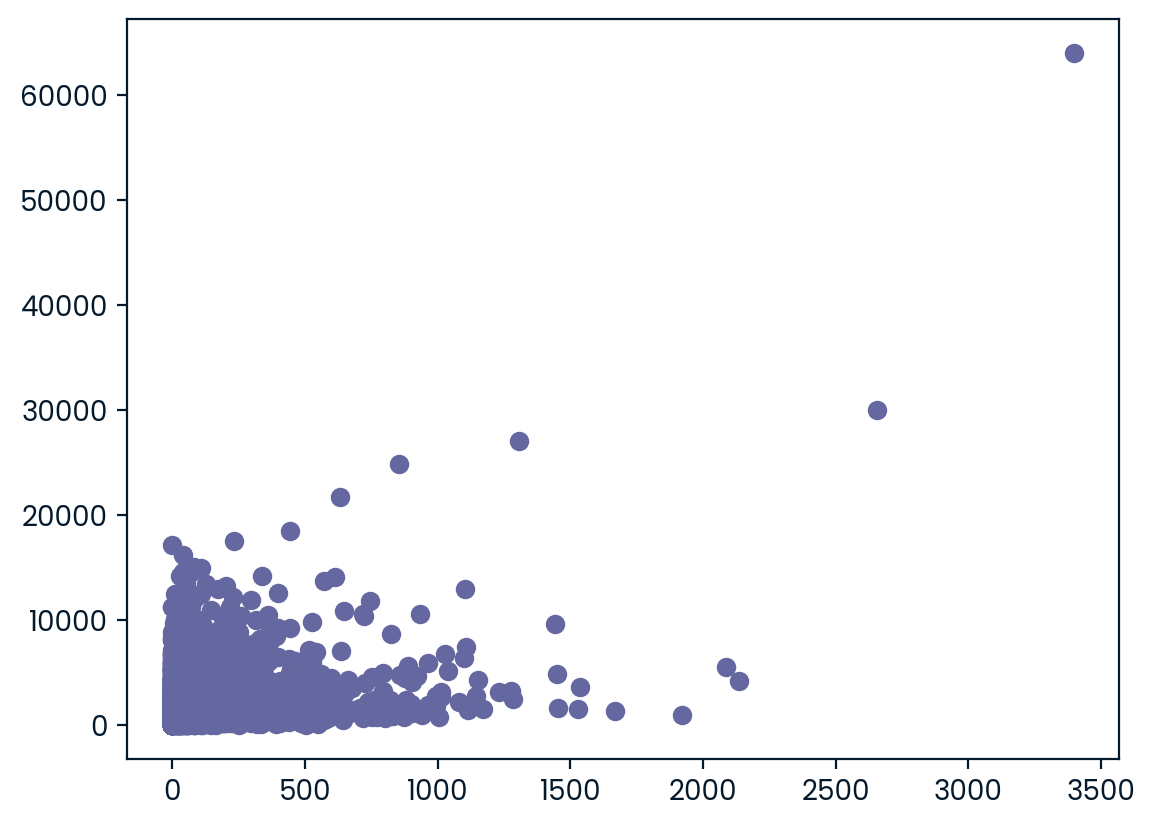

In [72]:
# Scatter plot
plt.scatter(df_month_returning['Administrative_Duration'], df_month_returning['ProductRelated_Duration'])
plt.show()

In [ ]:
# 15% rate campaign
campaign= purchase_rates['Returning_Customer'] * 1.15
print(campaign.round(3))

0.225


In [ ]:
# Probability of sales < 100 
prob_sales= stats.binom.cdf(k= 100, n= 500, p= campaign)
print(prob_sales.round(3))

0.099


In [ ]:
# Probability of at least 100 sales
prob_at_least_100_sales= 1 - prob_sales
print(prob_at_least_100_sales.round(3))

0.901


<b>Actividades:</b>
- Teniendo en cuenta el período de mayores ventas (Noviembre y Diciembre), almacenar tasas de retorno y de clientes nuevos en un diccionario.
- Averiguar la correlación más alta en las columnas de tipo Date y almacenarla en un diccionario.
- Obtener la tasa de retorno si se incrementa en 15%
- Obtener la probabilidad de que las ventas sean menores a 100 unidades.
- Obtener la probabilidad de que las ventas sean al menos de 100 unidades.
<br><br><br>

<b>Conclusiones:</b>
- Tasa de retorno de clientes: <b>19%</b>
- Clientes nuevos: <b>27%</b>
- <b>AdministrativeDuration</b> y <b>ProductRelated_Duration</b> con la correlación más alta <b>(0.417)</b>
- Probabilidad de ventas menores a 100 unidades: <b>9%</b>
- Probabilidad de tener al menos 100 ventas: <b>90%</b>